# Modelling

----

# Import Libraries:

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F 
from sklearn.model_selection import cross_val_score, train_test_split
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.window import Window
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pyspark.ml.regression import LinearRegression
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.functions import log1p
import os
import math
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("correlation_modelling")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.network.timeout", "600s")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.rpc.askTimeout", "600s")
    .config("spark.driver.memory", "100G")
    .config("spark.executor.memory", "100G")
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.sql.debug.maxToStringFields", "3000")
    .getOrCreate()
)

24/08/25 05:26:01 WARN Utils: Your hostname, Cocos-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 172.16.33.67 instead (on interface en0)
24/08/25 05:26:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/25 05:26:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/08/25 05:26:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


# Read Files:

In [3]:
base_dir = "../data"
plot_path = '../plots'

In [6]:
final_path = base_dir + '/developed/selected_trans_final_data'
final_sdf = spark.read.parquet(final_path)
final_sdf.show(5)

+-----+--------+-----------+--------------------+-------------------+-------------+---------------+-----------------------+------------------+------------------------+----------------+---------------+------------------------------+------------------------------+---+----------------+------------+----------------+----------------------------+----------------------------------+----------------+----------------+--------------+---------------+----------------+---------------------+----------------+----------------------------+------------+----------------------+----------------+----------------+----------------------------------+----------------+--------------+----------------+----------------+----------------+---------------+----------------+---------------+----------------+----------------+---+----------------+----------------+------------------------------+----------------+----------------+------------------------------+----------------+---------------------+--------------------------+--

In [5]:
final_sdf.printSchema()

root
 |-- month: integer (nullable = true)
 |-- day_type: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- avg_utilization_rate: double (nullable = true)
 |-- avg_trip_speed: double (nullable = true)
 |-- AvgHourlyTemp: double (nullable = true)
 |-- PULocationID_44: integer (nullable = true)
 |-- zone_Stuyvesant Heights: integer (nullable = true)
 |-- zone_Fordham South: integer (nullable = true)
 |-- zone_Ocean Parkway South: integer (nullable = true)
 |-- zone_Old Astoria: integer (nullable = true)
 |-- PULocationID_93: integer (nullable = true)
 |-- zone_Forest Park/Highland Park: integer (nullable = true)
 |-- zone_Times Sq/Theatre District: integer (nullable = true)
 |-- O: integer (nullable = true)
 |-- PULocationID_216: integer (nullable = true)
 |-- zone_Bedford: integer (nullable = true)
 |-- PULocationID_102: integer (nullable = true)
 |-- zone_Allerton/Pelham Gardens: integer (nullable = true)
 |-- zone_Sutton Place/Turtle Bay North: integer (nullab

# Linear Regression Model:

### Predicting `log_avg_hourly_demand`:

#### Create the Model:

In [5]:
excluded_column = 'log_avg_hourly_demand'
selected_columns = [col for col in final_sdf.columns if col not in excluded_column]

# Test month
target = 12

# Split the dataset
train_data = final_sdf.filter(final_sdf['month'] != target) # Train on July-November data
test_data = final_sdf.filter(final_sdf['month'] == target)  # Test on December data

In [7]:
# Define the required feature columns and create a VectorAssembler instance
features = 'features'
input_cols = selected_columns

demand_assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol=features,
    handleInvalid='skip'
)

# Apply transformation on training and test sets
train_data = demand_assembler.transform(train_data)
test_data = demand_assembler.transform(test_data)

In [8]:
# Create the model
lr_demand = LinearRegression(
    featuresCol=features, 
    labelCol='log_avg_hourly_demand'
)

#### Hyperparameter Tuning:

In [9]:
# Define the evaluator
demand_lr_evaluator = RegressionEvaluator(
    labelCol='log_avg_hourly_demand',
    predictionCol='prediction',
    metricName='rmse'
)

# Define the parameter grid
param_grid = (ParamGridBuilder()
    .addGrid(lr_demand.maxIter, [10, 50, 100])
    .addGrid(lr_demand.regParam, [0.0, 0.1, 0.2])
    .addGrid(lr_demand.elasticNetParam, [0.0, 0.5, 1.0])
    .build())

# Set up the cross-validation
crossval = CrossValidator(
    estimator=lr_demand,
    estimatorParamMaps=param_grid,
    evaluator=demand_lr_evaluator,
    numFolds=5
)

# Fit the model using cross-validation
cv_model = crossval.fit(train_data)

# Get the best model
best_demand_lr_model = cv_model.bestModel

24/08/25 02:49:41 WARN Instrumentation: [fba83da1] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 02:49:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
24/08/25 02:49:43 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
24/08/25 02:49:43 WARN Instrumentation: [fba83da1] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
24/08/25 02:50:53 WARN Instrumentation: [a80ef413] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 02:50:55 WARN Instrumentation: [a80ef413] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
24/08/25 02:50:57 WARN Instrumentation: [de3b517a] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 02:50:59 WARN Instrumentation: [de3b517a] Cholesky solver failed due to singular covariance matrix. Retryin

In [10]:
# Find the best model parameters
best_lr_model_params = {
    "maxIter": best_demand_lr_model._java_obj.getMaxIter(),
    "regParam": best_demand_lr_model._java_obj.getRegParam(),
    "elasticNetParam": best_demand_lr_model._java_obj.getElasticNetParam()
}

print("Best Linear Regression Model Parameters:")
print(f"Max Iterations: {best_lr_model_params['maxIter']}")
print(f"Regularization Parameter (regParam): {best_lr_model_params['regParam']}")
print(f"Elastic Net Parameter (elasticNetParam): {best_lr_model_params['elasticNetParam']}")

Best Linear Regression Model Parameters:
Max Iterations: 100
Regularization Parameter (regParam): 0.0
Elastic Net Parameter (elasticNetParam): 0.5


#### Prediction and Evaluation:

In [11]:
# Make prediciton on test data by the best model 
lr_revenue_predictions = best_demand_lr_model.transform(test_data)

# Evaluation
print("Evaluation of Linear Regression Model for log_avg_hourly_demand:")
print("Intercept: ", best_demand_lr_model.intercept)
print("R2: ", demand_lr_evaluator.setMetricName('r2').evaluate(lr_revenue_predictions))
print("RMSE: ", demand_lr_evaluator.setMetricName('rmse').evaluate(lr_revenue_predictions))

Evaluation of Linear Regression Model for log_avg_hourly_demand:
Intercept:  -2.1914825669123665


R2:  0.8671513128866448


RMSE:  0.4373723008947216


#### Plot the Feature Importance:

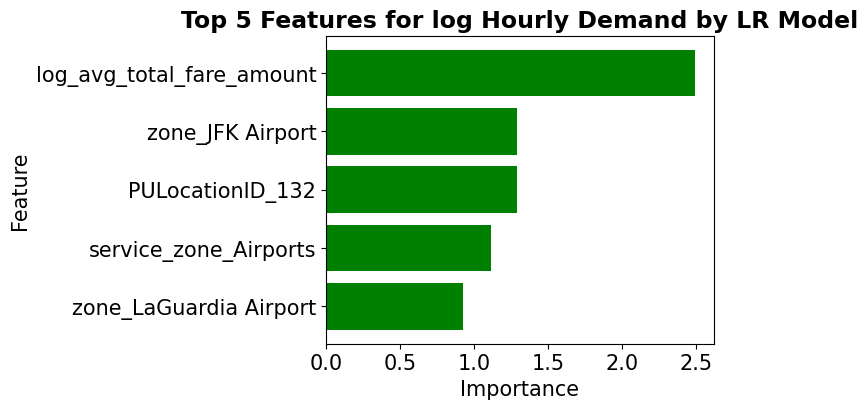

In [15]:
# Extract feature importances from the best Linear Regression model
feature_importances = best_demand_lr_model.coefficients.toArray()

# Create a DataFrame with feature names and their importances
feature_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
})

# Sort the DataFrame by importance and get the top 20 features
top_features = feature_df.sort_values(by='Importance', ascending=False).head(5)

# Plot the feature importances
plt.figure(figsize=(5, 3))
plt.barh(top_features['Feature'], top_features['Importance'], color='green')
plt.xlabel('Importance', fontsize=15)
plt.ylabel('Feature', fontsize=15)
plt.title('Top 5 Features for log Hourly Demand by LR Model', 
          weight='bold', fontsize=17)
plt.gca().invert_yaxis()  # To display the highest importance at the top

# Adjust the size of the tick labels on both axes
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Save and display the plot
file_name = 'top5_demand_features_lr.png'
file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

### Predicting `log_avg_total_revenue`:

#### Create the Model:

In [6]:
excluded_column = 'log_avg_total_revenue'
selected_columns = [col for col in final_sdf.columns if col not in excluded_column]

# Split the dataset
final_sdf = spark.read.parquet(final_path)
train_data = final_sdf.filter(final_sdf['month'] != target) # Train on July-November data
test_data = final_sdf.filter(final_sdf['month'] == target)  # Test on December data

In [7]:
# Define the required feature columns and create a VectorAssembler instance
features = 'features'
input_cols = selected_columns

revenue_assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol=features,
    handleInvalid='skip'
)

# Apply transformation on training and test sets
train_data = revenue_assembler.transform(train_data)
test_data = revenue_assembler.transform(test_data)

In [8]:
# Create the model
lr_revenue = LinearRegression(
    featuresCol=features, 
    labelCol='log_avg_total_revenue'
)

#### Hyperparameter Tuning:

In [9]:
# Define evaluation metrics
revenue_lr_evaluator = RegressionEvaluator(
    labelCol='log_avg_total_revenue',
    predictionCol='prediction',
    metricName='rmse'
)

# Define the parameter grid
param_grid = (ParamGridBuilder()
    .addGrid(lr_revenue.maxIter, [10, 50, 100])
    .addGrid(lr_revenue.regParam, [0.0, 0.1, 0.2])
    .addGrid(lr_revenue.elasticNetParam, [0.0, 0.5, 1.0])
    .build())

# Set up the cross-validation
crossval = CrossValidator(
    estimator=lr_revenue,
    estimatorParamMaps=param_grid,
    evaluator=revenue_lr_evaluator,
    numFolds=5 
)

# Fit the model using cross-validation
cv_model = crossval.fit(train_data)

# Get the best model
best_revenue_lr_model = cv_model.bestModel

24/08/25 03:44:24 WARN Instrumentation: [5570bbaa] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 03:44:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
24/08/25 03:44:26 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
24/08/25 03:44:26 WARN Instrumentation: [5570bbaa] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
24/08/25 03:44:55 WARN Instrumentation: [2929de39] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 03:44:57 WARN Instrumentation: [2929de39] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
24/08/25 03:44:58 WARN Instrumentation: [26652b51] regParam is zero, which might cause numerical instability and overfitting.
24/08/25 03:45:00 WARN Instrumentation: [26652b51] Cholesky solver failed due to singular covariance matrix. Retryin

In [10]:
# Find the best model parameters
best_lr_model_params = {
    "maxIter": best_revenue_lr_model._java_obj.getMaxIter(),
    "regParam": best_revenue_lr_model._java_obj.getRegParam(),
    "elasticNetParam": best_revenue_lr_model._java_obj.getElasticNetParam()
}

print("Best Linear Regression Model Parameters:")
print(f"Max Iterations: {best_lr_model_params['maxIter']}")
print(f"Regularization Parameter (regParam): {best_lr_model_params['regParam']}")
print(f"Elastic Net Parameter (elasticNetParam): {best_lr_model_params['elasticNetParam']}")

Best Linear Regression Model Parameters:
Max Iterations: 100
Regularization Parameter (regParam): 0.0
Elastic Net Parameter (elasticNetParam): 0.0


#### Prediction and Evaluation:

In [11]:
# Make prediciton on test data by the best model 
lr_revenue_predictions = best_revenue_lr_model.transform(test_data)

# Evaluation
print("Evaluation of Linear Regression Model for log_avg_total_revenue:")
print("Intercept: ", best_revenue_lr_model.intercept)
print("R2: ", revenue_lr_evaluator.setMetricName('r2').evaluate(lr_revenue_predictions))
print("RMSE: ", revenue_lr_evaluator.setMetricName('rmse').evaluate(lr_revenue_predictions))

Evaluation of Linear Regression Model for log_avg_total_revenue:
Intercept:  0.46722384507834475


R2:  0.9191948893277198


RMSE:  0.07584837140963038


#### Plot the Feature Importance:

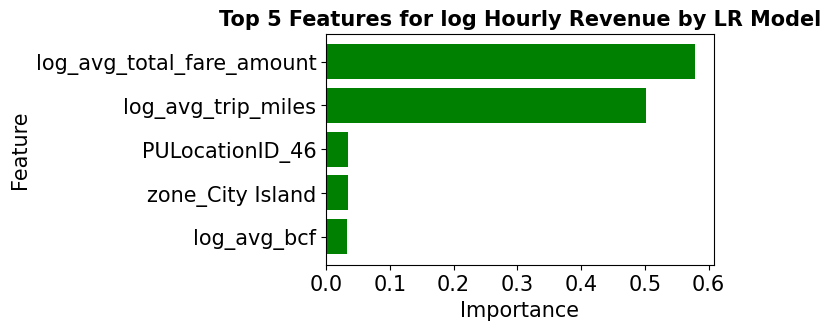

In [12]:
# Extract feature importances from the best Linear Regression model
feature_importances = best_revenue_lr_model.coefficients.toArray()

# Create a DataFrame with feature names and their importances
feature_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
})

# Sort the DataFrame by importance and get the top 20 features
top_features = feature_df.sort_values(by='Importance', ascending=False).head(5)

# Plot the feature importances
plt.figure(figsize=(5, 3))
plt.barh(top_features['Feature'], top_features['Importance'], color='green')
plt.xlabel('Importance', fontsize=15)
plt.ylabel('Feature', fontsize=15)
plt.title('Top 5 Features for log Hourly Revenue by LR Model', 
          weight='bold', fontsize=15)
plt.gca().invert_yaxis()  # To display the highest importance at the top

# Adjust the size of the tick labels on both axes
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# Save and display the plot
file_name = 'top5_revenue_features_lr.png'
file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

# Random Forest Regressor:

Due to high computation time (it does not stop after more than 240 minutes) caused by large amount of data, we will not use grid search on hyperparameter tuning for rhis model(and I also try to sample 5% of original data, it also does not work). The results display can get minimum RMSE by manully try some combinations of parameters.

In [4]:
# Test month
target = 12

### Predicting `log_avg_hourly_demand`:

#### Create the Model:

In [8]:
excluded_column = 'log_avg_hourly_demand'
final_sdf = spark.read.parquet(final_path)
selected_columns = [col for col in final_sdf.columns if col not in excluded_column]

# Split the dataset
train_data = final_sdf.filter(final_sdf['month'] != target) # Train on July-November data
test_data = final_sdf.filter(final_sdf['month'] == target)  # Test on December data

In [9]:
# Define the required feature columns and create a VectorAssembler instance
features = 'features'
input_cols = selected_columns

demand_assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol=features,
    handleInvalid='skip'
)

# Apply transformation on training and test sets
train_data = demand_assembler.transform(train_data)
test_data = demand_assembler.transform(test_data)

In [10]:
# Create the Random Forest model
rf_demand = RandomForestRegressor()
rf_demand = RandomForestRegressor(maxDepth=10, featureSubsetStrategy='onethird')
rf_demand = rf_demand.setFeaturesCol('features').setLabelCol('log_avg_hourly_demand')

# Fit the Random Forest model
rf_demand_model = rf_demand.fit(train_data)

24/08/24 16:40:44 WARN DAGScheduler: Broadcasting large task binary with size 1042.0 KiB
24/08/24 16:40:51 WARN DAGScheduler: Broadcasting large task binary with size 1675.5 KiB
24/08/24 16:41:01 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
24/08/24 16:41:15 WARN DAGScheduler: Broadcasting large task binary with size 5.2 MiB
24/08/24 16:41:37 WARN DAGScheduler: Broadcasting large task binary with size 9.4 MiB


#### Evaluation and Prediction:

In [11]:
# Make predictions on the test data using the best model
rf_demand_predictions = rf_demand_model.transform(test_data)

# Initialize RegressionEvaluator
rf_demand_evaluator = RegressionEvaluator(
    labelCol='log_avg_hourly_demand', 
    predictionCol='prediction', 
    metricName='rmse'
)

# Evaluation
print("Evaluation of Random Forest Regressor Model for log_avg_hourly_demand:")
print("RMSE: ", rf_demand_evaluator.evaluate(rf_demand_predictions))

Evaluation of Random Forest Regressor Model for log_avg_hourly_demand:


RMSE:  0.49468788545120235


#### Plot the Feature Importance:

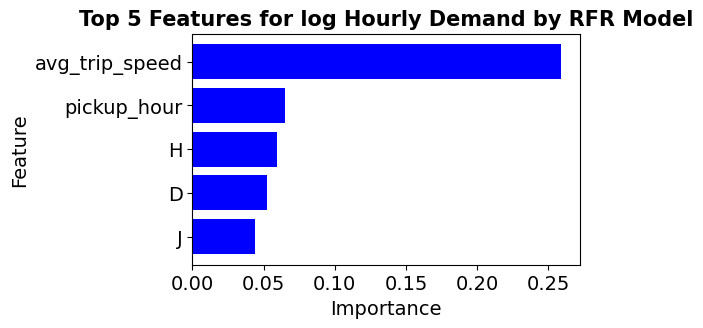

In [27]:
# Extract feature importances from the best Random Forest model
feature_importances = rf_demand_model.featureImportances.toArray()

# Create a DataFrame with feature names and their importances
feature_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
})

# Sort the DataFrame by importance and get the top 20 features
top_features = feature_df.sort_values(by='Importance', ascending=False).head(5)

# Plot the feature importances
plt.figure(figsize=(5, 3))
plt.barh(top_features['Feature'], top_features['Importance'], color='blue')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 5 Features for log Hourly Demand by RFR Model', 
          weight='bold', fontsize=15)
plt.gca().invert_yaxis()  # To display the highest importance at the top

# Adjust the size of the tick labels on both axes
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Save and display the plot
file_name = 'top5_demand_features_rf.png'
file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()

### Predicting `log_avg_total_revenue`:

#### Create the Model:

In [7]:
excluded_column = 'log_avg_total_revenue'
selected_columns = [col for col in final_sdf.columns if col not in excluded_column]

# Split the dataset
final_sdf = spark.read.parquet(final_path)
train_data = final_sdf.filter(final_sdf['month'] != target) # Train on July-November data
test_data = final_sdf.filter(final_sdf['month'] == target)  # Test on December data

In [8]:
# Define the required feature columns and create a VectorAssembler instance
features = 'features'
input_cols = selected_columns

revenue_assembler = VectorAssembler(
    inputCols=input_cols,
    outputCol=features,
    handleInvalid='skip'
)

# Apply transformation on training and test sets
train_data = revenue_assembler.transform(train_data)
test_data = revenue_assembler.transform(test_data)

In [9]:
# Create the Random Forest model
rf_revenue = RandomForestRegressor()
rf_revenue = RandomForestRegressor(maxDepth=10, featureSubsetStrategy='onethird')
rf_revenue = rf_revenue.setFeaturesCol('features').setLabelCol('log_avg_total_revenue')

# Fit the Random Forest model
rf_revenue_model = rf_revenue.fit(train_data)

24/08/25 05:28:55 WARN DAGScheduler: Broadcasting large task binary with size 1051.3 KiB
24/08/25 05:29:04 WARN DAGScheduler: Broadcasting large task binary with size 1695.1 KiB
24/08/25 05:29:16 WARN DAGScheduler: Broadcasting large task binary with size 2.9 MiB
24/08/25 05:29:34 WARN DAGScheduler: Broadcasting large task binary with size 5.4 MiB
24/08/25 05:29:56 WARN DAGScheduler: Broadcasting large task binary with size 10.0 MiB


#### Evaluation and Prediction:

In [10]:
# Make predictions on the test data using the best model
rf_revenue_predictions = rf_revenue_model.transform(test_data)

# Initialize RegressionEvaluator
rf_revenue_evaluator = RegressionEvaluator(
    labelCol='log_avg_total_revenue',
    predictionCol='prediction',
    metricName='rmse'
)

# Evaluation
print("Evaluation of Random Forest Regressor Model for log_avg_total_revenue:")
print("RMSE: ", rf_revenue_evaluator.evaluate(rf_revenue_predictions))

Evaluation of Random Forest Regressor Model for log_avg_total_revenue:


RMSE:  0.08455627132431726


#### Plot the Feature Importance:

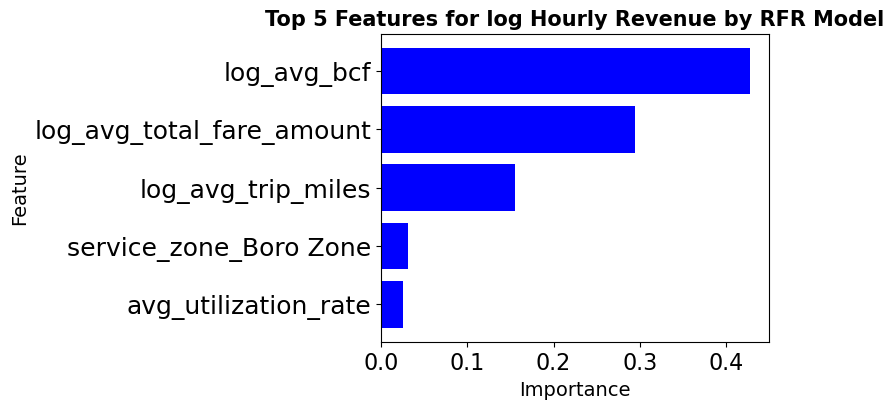

24/08/25 07:07:19 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 908510 ms exceeds timeout 600000 ms
24/08/25 07:07:19 WARN SparkContext: Killing executors is not supported by current scheduler.
24/08/25 07:07:22 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [25]:
# Extract feature importances from the best Random Forest model
feature_importances = rf_revenue_model.featureImportances.toArray()

# Create a DataFrame with feature names and their importances
feature_df = pd.DataFrame({
    'Feature': input_cols,
    'Importance': feature_importances
})

# Sort the DataFrame by importance and get the top 20 features
top_features = feature_df.sort_values(by='Importance', ascending=False).head(5)

# Plot the feature importances
plt.figure(figsize=(5, 4))
plt.barh(top_features['Feature'], top_features['Importance'], color='blue')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.title('Top 5 Features for log Hourly Revenue by RFR Model', 
          weight='bold', fontsize=15)
plt.gca().invert_yaxis()  # To display the highest importance at the top

# Adjust the size of the tick labels on both axes
plt.xticks(np.arange(0.0, 0.5, 0.1), fontsize=16)
plt.yticks(fontsize=18)

# Save and display the plot
file_name = 'top5_revenue_features_rf.png'
file_path = os.path.join(plot_path, file_name)
plt.savefig(file_path, dpi=300, bbox_inches='tight')

plt.show()